# M5 — CDOM Fluorescence: the Analytic Term and Its Interface

The fifth milestone notebook of the inelastic RT effort, and the first of the
CDOM-fluorescence design (`design/rt_cdom_fluorescence_model.md`, executed by
`claude_prompts/RT/rt_cdom_coding_prompt_1.md` on branch `cdom-rt`). The
shipped Raman + chlorophyll-fluorescence prototype (M0–M4,
`reports/report_rt_inelastic_model.md`) reproduces the all-processes-on L23
ocean to 0.34 % held-out rRMS — but L23 *omits CDOM fluorescence by design*,
and BING never implemented it, so the third inelastic term arrives with **no
truth channel anywhere in hand**. M5 therefore ships the term
**analytic-only, default-off, and unvalidated until M6**.

This notebook demonstrates what M5 *decided*, live — nothing here is
transcribed, every headline number is recomputed and asserted against its
committed pin (the M4 notebook's no-transcription rule):

1. **The Hawes basis** — which published function and whose constants (§1);
2. **the 350 nm excitation clamp** and its measured truncated-fraction cost (§2);
3. **why `cdom_fl=None` default-off is load-bearing**, shown bitwise (§3);
4. **the literature-plausibility table** on the full L23 release (§4);
5. **the rescoped, machine-anchored speed budget** — the honest CQ3 story (§5);
6. **what is *not* done** — the M6 boundary (§6).

Implementation record: `design/rt_inelastic_implementation.md` §8.


## 1. The Hawes basis: FA7, Gaussian in wavenumber

The kernel's redistribution function is the Hawes et al. (1992) spectral
fluorescence quantum efficiency `η_Y(λ, λ_e)` in the form given by
Zhai, Hu, Lee et al. (2017), *Optics Express* 25(8), Eqs. (7)–(8): for each
excitation wavelength λ_e, the emission distribution is a Gaussian **in
wavenumber** (reciprocal wavelength) whose center `A1/λ_e + B1`, width
`0.6·(A2/λ_e + B2)`, and amplitude `A0(λ_e)` all move with λ_e — genuinely
**non-separable** in (λ, λ_e), unlike the Chl-a 685 nm line. The constants are
the Hawes **Station FA7** fulvic-acid fit — HydroLight's own default CDOM
choice, so the eventual design-§7 truth runs share constants with this kernel
by construction.


repo   : /Users/xavier/Oceanography/python/retrieve-or-bust
Python 3.14.6, jax 0.11.0, backend cpu

Hawes (1992) Station FA7 constants (Ocean Optics Web Book; accepted per Q&A CQ2):
  A1 = 0.47   (dimensionless)
  B1 = 8.0770e-04 nm^-1
  A2 = 0.407   (dimensionless)
  B2 = -4.570e-04 nm^-1
  A0(lambda_e) tabulated at 10 nodes, 310-490 nm (linearly interpolated between them)



lambda_e = 350 nm: eta_Y peaks at 465 nm (red-shifted +115 nm), peak value 8.00e-05 nm^-1
lambda_e = 390 nm: eta_Y peaks at 497 nm (red-shifted +107 nm), peak value 9.39e-05 nm^-1
lambda_e = 430 nm: eta_Y peaks at 526 nm (red-shifted +96 nm), peak value 1.26e-04 nm^-1
lambda_e = 470 nm: eta_Y peaks at 553 nm (red-shifted +83 nm), peak value 1.36e-04 nm^-1


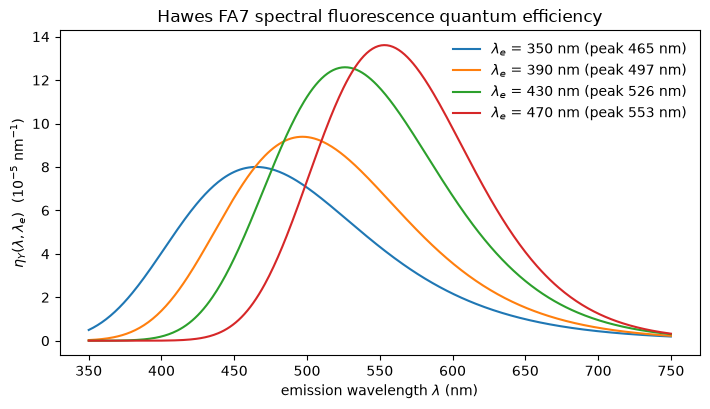

In [1]:
import sys
from pathlib import Path

# This notebook lives in notebooks/RT/. `robust` is not pip-installed in
# `ocean14` (deliberately -- the JAX stack only), so put the repo root on
# sys.path, exactly as the earlier milestone notebooks do.
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'robust' / '__init__.py').exists())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from robust.rt import cdom_fl as CF

print(f'repo   : {REPO}')
print(f'Python {sys.version.split()[0]}, jax {jax.__version__}, '
      f'backend {jax.default_backend()}\n')

print('Hawes (1992) Station FA7 constants '
      '(Ocean Optics Web Book; accepted per Q&A CQ2):')
print(f'  A1 = {CF.HAWES_A1}   (dimensionless)')
print(f'  B1 = {CF.HAWES_B1:.4e} nm^-1')
print(f'  A2 = {CF.HAWES_A2}   (dimensionless)')
print(f'  B2 = {CF.HAWES_B2:.3e} nm^-1')
print(f'  A0(lambda_e) tabulated at {len(CF.HAWES_A0_WAVE)} nodes, '
      f'{CF.HAWES_A0_WAVE.min():.0f}-{CF.HAWES_A0_WAVE.max():.0f} nm '
      '(linearly interpolated between them)\n')

wave_em = jnp.arange(350.0, 751.0, 1.0)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
for lam_e in (350.0, 390.0, 430.0, 470.0):
    eta = CF.eta_hawes(wave_em, lam_e)
    peak = float(wave_em[int(jnp.argmax(eta))])
    ax.plot(wave_em, 1e5 * eta,
            label=f'$\\lambda_e$ = {lam_e:.0f} nm (peak {peak:.0f} nm)')
    print(f'lambda_e = {lam_e:.0f} nm: eta_Y peaks at {peak:.0f} nm '
          f'(red-shifted {peak - lam_e:+.0f} nm), '
          f'peak value {float(eta.max()):.2e} nm^-1')
ax.set_xlabel('emission wavelength $\\lambda$ (nm)')
ax.set_ylabel('$\\eta_Y(\\lambda, \\lambda_e)$  ($10^{-5}$ nm$^{-1}$)')
ax.set_title('Hawes FA7 spectral fluorescence quantum efficiency')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


**Provenance, plainly.** The *functional form* above (and the ≥ 350 nm
excitation floor) is peer-reviewed-verified — Zhai et al. (2017) Eqs. (5)–(8),
extracted verbatim from the published PDF. The *FA7 numeric constants* were
sourced from Mobley's **Ocean Optics Web Book** (retrieved 2026-08-29 via an
AI-mediated fetch of the JS-rendered page) and could not be corroborated
against a second source at implementation time; the question was posed to JXP
(prompt-doc Q&A CQ2) and **JXP accepted the OOWB as the source** (2026-08-30:
*"I don't have access but I am good with the Ocean Optics Web Book"*). The
constants are therefore recorded as *sourced from OOWB, accepted without
independent primary-source verification* — honest provenance, not a
peer-review claim, and no longer an open action item. The §5.2 correctness pin
(`test_a0_table_reproduced_at_the_gaussian_peak`) pins exactly these values.

One physics honesty note, visible in the figure: the Gaussian-in-wavenumber
form red-shifts the emission *peak* for every admissible λ_e, but it does
**not** enforce a strict Stokes shift — the blue tail at λ = λ_e is real
(~6 % of peak at 350 nm, ~22 % at 490 nm). The tests pin the red-shifted peak
and assert the tail subdominant; nothing asserts it away.


## 2. The 350 nm clamp, and what it measurably costs

`g_Y` admits excitation down to 310 nm, but the L23/IOP/Ed grids start at
350 nm, so the production excitation quadrature **starts** at 350 nm — the
clamp is the grid, not arithmetic, which is what makes "the kernel never reads
IOPs or Ed below 350 nm" provable (a spy test pins it at the seams). What the
clamp throws away is the committed task-4 diagnostic
`truncated_excitation_fraction(λ)`: the fraction of the Hawes function's
nominal 310–490 nm-excited emission that sub-350 nm excitation would have
contributed, per emission wavelength — from the FA7 function alone (no IOPs,
no Ed, no scene). Recomputed here and asserted against the pinned table
(implementation record §8.5):


In [2]:
from robust.rt import conventions as C

# The record-8.5 table (also pinned banded +/-0.03 by
# test_truncated_fraction_pinned_at_representative_wavelengths).
PINNED = {350: 0.846, 400: 0.566, 450: 0.297, 500: 0.142, 550: 0.083,
          600: 0.070, 650: 0.078, 700: 0.103, 750: 0.146}

wave = C.canonical_wave()
frac = CF.truncated_excitation_fraction(wave)

print(' lambda_em   truncated fraction   record-8.5 pin')
for lam, pin in PINNED.items():
    val = float(frac[int(jnp.argmin(jnp.abs(wave - lam)))])
    assert abs(val - pin) <= 0.03, (lam, val, pin)
    print(f'   {lam:4d} nm         {val:6.3f}            {pin:.3f}')
print('\nAll nine recomputed values agree with the committed pins (+/-0.03).')
print(f'Minimum over the canonical grid: '
      f'{float(frac.min()):.3f} at {float(wave[int(jnp.argmin(frac))]):.0f} nm')


 lambda_em   truncated fraction   record-8.5 pin
    350 nm          0.846            0.846
    400 nm          0.566            0.566
    450 nm          0.297            0.297
    500 nm          0.142            0.142
    550 nm          0.083            0.083
    600 nm          0.070            0.070
    650 nm          0.078            0.078
    700 nm          0.103            0.103
    750 nm          0.146            0.146

All nine recomputed values agree with the committed pins (+/-0.03).
Minimum over the canonical grid: 0.070 at 605 nm


**The caveat, stated plainly:** at λ = 400 nm, **57 %** of the nominal
310–490 nm-excited Hawes emission is excluded by the clamp (85 % at 350 nm,
30 % at 450 nm; minimum ~7 % near 605 nm) — the design-§8 blue-band risk,
realized and recorded rather than asserted away. Two softenings, both honest:
these are properties of the η_Y redistribution *alone* — the realized Rrs
truncation is further suppressed by the `a_cdom(λ_e)·Ed(λ_e)` weighting, and
sub-350 nm surface Ed is strongly suppressed (ozone + solar spectrum — Zhai et
al.'s own rationale for imposing the identical clamp). This table is the
standing caveat quoted wherever the term's output is quoted; the design-§7
HydroLight runs resolve how much of it survives the Ed weighting.


## 3. Why `cdom_fl=None` default-off is load-bearing

The shipped X4 truth **omits CDOM fluorescence**, so the report's 0.34 % rRMS
gate — and every claim built on it — remains valid only while the default
model is provably CDOM-fl-free. That is why `Inelastic()` keeps
`cdom_fl=None` even now that the term exists, and why the off-state is pinned
**bitwise** (two-tier: strict SHA-256 on the anchoring machine, ULP-closeness
everywhere). Below, live on the committed 50-scene CI fixture: the default
forward is bit-identical whether or not the IOPs carry an (unused) `a_cdom`,
and identical again with `cdom_fl=None` spelled explicitly; switching the term
**on** changes the output *only* additively, by exactly `scale · K_cdom`.


In [3]:
import dataclasses
import hashlib

import robust
from robust.rt import forward
from robust.rt.data import l23
from robust.rt.types import CDOMFl, Inelastic

FILES = Path(robust.__file__).parent / 'tests' / 'files'
batch = l23.load_inelastic_batch(
    reader=l23.inelastic_npz_reader(FILES / 'l23_inelastic_fixture.npz',
                                    FILES / 'l23_small.npz'))
args = (batch.phase_params, batch.geometry, batch.wave)
sha = lambda x: hashlib.sha256(np.asarray(x).tobytes()).hexdigest()  # noqa: E731

rrs_default = forward(batch.iops, *args, 'hybrid',
                      inelastic=Inelastic(), check_domain=False)
rrs_no_acdom = forward(dataclasses.replace(batch.iops, a_cdom=None), *args,
                       'hybrid', inelastic=Inelastic(), check_domain=False)
rrs_explicit = forward(batch.iops, *args, 'hybrid',
                       inelastic=Inelastic(cdom_fl=None), check_domain=False)

print(f'default,  a_cdom set (unused): {sha(rrs_default)[:16]}...')
print(f'default,  a_cdom=None        : {sha(rrs_no_acdom)[:16]}...')
print(f'explicit  cdom_fl=None       : {sha(rrs_explicit)[:16]}...')
assert sha(rrs_default) == sha(rrs_no_acdom) == sha(rrs_explicit)
print('bit-identical, all three -- the CDOM branch is unreachable when off,')
print('by construction, not by arithmetic.\n')

rrs_on = forward(batch.iops, *args, 'hybrid',
                 inelastic=Inelastic(cdom_fl=CDOMFl()), check_domain=False)
k_cdom_fix = CF.cdom_kernel(batch.iops, batch.geometry, batch.wave)
np.testing.assert_allclose(np.asarray(rrs_on),
                           np.asarray(rrs_default) + np.asarray(k_cdom_fix),
                           rtol=5e-6, atol=1e-10)
delta = np.asarray(rrs_on) - np.asarray(rrs_default)
print('cdom_fl=CDOMFl() on: output changes only additively, by K_cdom')
print(f'  (asserted at rtol 5e-6; median added term '
      f'{np.median(delta / np.asarray(rrs_default)) * 100:.2f} % of Rrs '
      'on the fixture).')


default,  a_cdom set (unused): 0dd365158e303726...
default,  a_cdom=None        : 0dd365158e303726...
explicit  cdom_fl=None       : 0dd365158e303726...
bit-identical, all three -- the CDOM branch is unreachable when off,
by construction, not by arithmetic.



cdom_fl=CDOMFl() on: output changes only additively, by K_cdom
  (asserted at rtol 5e-6; median added term 0.74 % of Rrs on the fixture).


The same identity is what the committed regression pins permanently:
`test_inelastic_default_hash_regression_strict` /
`..._regression_close_everywhere` (`PRE_CDOM_SHA256_*`, pinned on the
unmodified code *before* the composition was wired), alongside the original
elastic pins. Note the machine-anchoring asymmetry recorded at task 5: the
elastic pins were anchored on the tank server, the pre-CDOM pins on this Mac —
on any one machine, one strict set may fail while the other passes; the
closeness tiers carry the guard everywhere.


## 4. Plausibility on the full L23 release — live

Design §5.3, the truth-less stand-in for validation: on real L23 IOPs the
unit-scale CDOM-fl contribution should sit at *a few percent* of Rrs in the
blue-green for CDOM-rich scenes, ≲ 1 % for oligotrophic ones, and be monotone
in a_cdom(440). Recomputed here on the full release (needs `$OS_COLOR`; this
cell degrades to a note if the data is absent): `K_cdom / Rrs_elastic`, mean
over 440–500 nm, per a_cdom(440) decile.


In [4]:
from robust.rt import hybrid as H
from robust.rt import validation as V

try:
    release = l23.load_inelastic_batch()
except Exception as err:  # noqa: BLE001 -- any load failure degrades to a note
    release = None
    print('L23 full release unavailable on this machine '
          f'({type(err).__name__}). Skipping the live plausibility and speed '
          'sections; the committed numbers live in '
          'design/rt_inelastic_implementation.md section 8.8 and are gated by '
          'robust/tests/test_cdom_validation.py.')

if release is not None:
    rrs_el = np.asarray(H.forward(release.iops, release.phase_params,
                                  release.geometry, release.wave, 'hybrid',
                                  check_domain=False))
    k_cdom = np.asarray(CF.cdom_kernel(release.iops, release.geometry,
                                       release.wave))
    w = np.asarray(release.wave)
    band = (w >= 440.0) & (w <= 500.0)
    fraction = (k_cdom[:, band] / rrs_el[:, band]).mean(axis=1)
    i440 = int(np.abs(w - 440.0).argmin())
    a440 = np.asarray(release.iops.a_cdom)[:, i440]
    labels, _ = V.quantile_bin_labels(a440, n_bins=10)

    print(f'{len(fraction)} scenes; K_cdom (unit scale) / elastic Rrs, '
          'mean over 440-500 nm:\n')
    print(' decile   a_cdom(440) med   mean frac   median frac')
    means = []
    for d in range(10):
        sel = labels == d
        means.append(fraction[sel].mean())
        print(f'    {d}          {np.median(a440[sel]):.4f}       '
              f'{means[-1] * 100:7.2f} %    {np.median(fraction[sel]) * 100:7.2f} %')
    means = np.array(means)
    assert np.all(np.diff(means) > 0.0)
    assert 0.003 <= means[-1] <= 0.15 and means[0] <= 0.012
    print('\nStrictly increasing across all ten deciles; top decile '
          f'{means[-1] * 100:.2f} % (loose "a few percent" band), bottom '
          f'{means[0] * 100:.2f} % (oligotrophic <~1 %) -- the gate of '
          'test_cdom_gate_3_plausibility_band, re-verified live.')


9960 scenes; K_cdom (unit scale) / elastic Rrs, mean over 440-500 nm:

 decile   a_cdom(440) med   mean frac   median frac
    0          0.0016          0.30 %       0.30 %
    1          0.0027          0.47 %       0.46 %
    2          0.0037          0.63 %       0.62 %
    3          0.0048          0.78 %       0.77 %
    4          0.0059          0.95 %       0.94 %
    5          0.0074          1.14 %       1.13 %
    6          0.0095          1.40 %       1.41 %
    7          0.0125          1.74 %       1.72 %
    8          0.0183          2.30 %       2.25 %
    9          0.0381          4.16 %       3.65 %

Strictly increasing across all ten deciles; top decile 4.16 % (loose "a few percent" band), bottom 0.30 % (oligotrophic <~1 %) -- the gate of test_cdom_gate_3_plausibility_band, re-verified live.


Read the table for what it is: a **loose characterization**, not a validation
— there is no truth to tighten it against (the gate's own docstring says so).
The monotone decile sequence is the strongest structural claim available
without truth: more CDOM in, more CDOM fluorescence out, everywhere in the
distribution. Gradients (design §5.4) are gated in the suite the same day:
all eight inputs — including the new `a_cdom` and `CDOMFl.scale` — agree with
float64 central differences to ≤ 2.2e-8, four orders under the 1e-6 bar.


## 5. Speed — the rescoped, machine-anchored budget (CQ3)

The design's original §5 item 5 read "≤ 2× the elastic hybrid" — the budget
inherited from the shipped M4 model. The task-7 gate, written to that bar,
**failed reproducibly on this Mac**: everything-on/elastic median 2.26–2.34×
(2.45× under concurrent load), while the *shipped* Raman+Chl-fl model alone —
which recorded 1.59× at its M4 acceptance on the tank server — measures ~1.9×
here the same day, and the CDOM-only forward ~1.4×. So the CDOM marginal is a
modest ~0.3–0.4× elastic; most of the budget was consumed by baseline drift on
this machine before CDOM arrived. The failure was left *gating* and the
decision escalated (Q&A CQ3). **JXP: "Go ahead and rescope the budget and make
note that it is machine-anchored."** The bound is now
`CDOM_GATE_SPEED_MACHINE_ANCHORED = 2.6` — machine-anchored in exactly the
strict-hash-pin sense: it characterizes *this machine's* measured behavior
(medians 2.30–2.34 quiet, plus headroom for load), not a portable physical
requirement; a different machine may reproduce a different, possibly tighter,
ratio. The shipped M4 record's own `INELASTIC_GATE_SPEED = 2.0` is untouched.
Measured live:


In [5]:
from robust.tests.test_cdom_validation import CDOM_GATE_SPEED_MACHINE_ANCHORED

if release is None:
    print('(skipped -- no L23 release on this machine; see section 4)')
else:
    from robust.rt import emulator as E
    from robust.rt import inelastic_corr as IC

    em = E.load_default()
    heads = IC.load_default()
    sargs = (release.iops, release.phase_params, release.geometry,
             release.wave)

    @jax.jit
    def everything_on(i, p, g, w):
        return H.forward(i, p, g, w, 'hybrid',
                         inelastic=Inelastic(cdom_fl=CDOMFl()),
                         corrections=heads, emulator=em, check_domain=False)

    @jax.jit
    def cdom_only(i, p, g, w):
        return H.forward(i, p, g, w, 'hybrid',
                         inelastic=Inelastic(raman=False, fluorescence=False,
                                             cdom_fl=CDOMFl()),
                         emulator=em, check_domain=False)

    @jax.jit
    def elastic(i, p, g, w):
        return H.forward(i, p, g, w, 'hybrid', emulator=em,
                         check_domain=False)

    ratios = [V.speed_ratio(everything_on, elastic, *sargs, repeats=5,
                            reverse=bool(t % 2))[0] for t in range(3)]
    med = float(np.median(ratios))
    marginal = V.speed_ratio(cdom_only, elastic, *sargs, repeats=5)[0]
    verdict = 'PASS' if med <= CDOM_GATE_SPEED_MACHINE_ANCHORED else 'FAIL'
    print(f'everything-on / elastic : median {med:.2f}x   '
          f"(trials {[f'{r:.2f}' for r in ratios]})")
    print(f'CDOM-only / elastic     : {marginal:.2f}x   (the marginal -- '
          'reported, never gated)')
    print(f'machine-anchored budget : <= {CDOM_GATE_SPEED_MACHINE_ANCHORED}x'
          f'   -> {verdict}')
    assert med <= CDOM_GATE_SPEED_MACHINE_ANCHORED


everything-on / elastic : median 2.31x   (trials ['2.37', '2.31', '2.31'])
CDOM-only / elastic     : 1.42x   (the marginal -- reported, never gated)
machine-anchored budget : <= 2.6x   -> PASS


## 6. What M5 does *not* deliver — the M6 boundary

No accuracy claim of any kind. There is no CDOM-fluorescence truth anywhere in
hand — L23 omits the process by design, BING never implemented it — so M5 has
**no held-out rRMS gate, no trained correction head, and no quantitative
validation**: the δ_C head is defined, zero-initialized (so the untrained head
is exactly the analytic backbone, bitwise), deliberately *not* wired into
`forward()`, and its training entry point raises naming M6; the term is
"Hawes-consistent and plausible", never "validated" — **unvalidated until
M6**, and default-off precisely so that nothing shipped depends on it being
right. M6 unblocks when the HydroLight "X4 vs X4 + CDOM-fl" paired runs exist
— the commissioning spec is `design/rt_cdom_fluorescence_model.md` §7, and the
M5/M6 split and its gates are §6 of the same design. Until those runs land,
this notebook and the §8 implementation record are the term's complete public
story: an analytic Hawes FA7 kernel with a documented clamp caveat, a complete
differentiable interface, a bitwise-provable off-state, and a
machine-anchored speed budget — ready for truth, and honest about not having
met any yet.
